In [8]:
import sys, os, importlib
sys.path.append('../')

import scripts.analytics
import scripts.algorithms

f = sys.stdout
sys.stdout = open(os.devnull, 'w')

importlib.reload(scripts.analytics)
importlib.reload(scripts.algorithms)

import numpy as np
import pandas as pd

sys.stdout.close()
sys.stdout = f

In [2]:
dsetname = "studentportuguese"
dsetnamex = "Portuguese"

d = 30

######
graphsx = np.load("../graphs/"+dsetname+"_knn_random.npy", allow_pickle=True)


## Info on the graphs

In [3]:
######
randomgraphsinfo = pd.read_csv("../graphs/studentportuguese_knn_graphsummary.npy")
randomgraphsinfo


,Dataset (d),kmax,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Student-portguese (30),1,224,46,20,26,1.0,0.486607,0.513393,4.869565,0.033352,0.017417,0.015935,109,115,0,0,0
1,Student-portguese (30),2,224,48,20,28,2.0,0.982143,1.017857,9.333333,0.140415,0.078075,0.062340,70,74,0,0,1
2,Student-portguese (30),3,224,48,20,28,3.0,1.540179,1.459821,14.000000,0.301650,0.179012,0.122638,38,36,0,0,2
3,Student-portguese (30),4,224,49,21,28,4.0,2.120536,1.879464,18.285714,0.528828,0.324952,0.203876,26,22,0,0,3
4,Student-portguese (30),5,224,50,22,28,5.0,2.656250,2.343750,22.400000,0.819827,0.505445,0.314382,17,13,0,0,4
5,Student-portguese (30),6,224,50,22,28,6.0,3.245536,2.754464,26.880000,1.146621,0.726297,0.420324,12,8,0,0,5
6,Student-portguese (30),7,224,50,22,28,7.0,3.781250,3.218750,31.360000,1.535714,0.975336,0.560378,3,6,0,0,6
7,Student-portguese (30),8,224,50,22,28,8.0,4.348214,3.651786,35.840000,1.973374,1.259009,0.714366,3,2,0,0,7
8,Student-portguese (30),9,224,50,22,28,9.0,4.955357,4.044643,40.320000,2.506246,1.621076,0.885170,1,1,0,0,8
9,Student-portguese (30),10,224,50,22,28,10.0,5.571429,4.428571,44.800000,3.055133,1.991832,1.063301,1,0,0,0,9


## Learning

In [4]:
summary_dfx = scripts.algorithms.learn_greedy(datagraphs=graphsx, 
                                               dim=d,
                                               savedname=dsetname,
                                               thresh=False)

summary_dfx.to_csv("./ls_results/"+dsetname+"_learn_results_knn.csv", index=False)
summary_dfx.head(10)

,K,dataset,graphid,kmax,n,m,tr_utility,ts_utility,tr_size,ts_size,...,ts_only-Ns,tr_empty_adj,ts_empty_adj,tr_perf1,ts_perf1,tr_perf2,ts_perf2,tr_perf3,ts_perf3,greedyTime
0,1,studentportuguese (30),0,1,224,46,76.200,32.800,156.0,68.0,...,35.20,0.0,0.0,100.00000,100.00000,48.84620,48.23525,0.00000,0.00000,0.032476
1,2,studentportuguese (30),0,1,224,46,76.200,32.800,156.0,68.0,...,35.20,0.0,0.0,100.00000,100.00000,48.84620,48.23525,0.00000,0.00000,0.030718
2,3,studentportuguese (30),0,1,224,46,76.200,32.800,156.0,68.0,...,35.20,0.0,0.0,100.00000,100.00000,48.84620,48.23525,0.00000,0.00000,0.031445
3,4,studentportuguese (30),0,1,224,46,76.200,32.800,156.0,68.0,...,35.20,0.0,0.0,100.00000,100.00000,48.84620,48.23525,0.00000,0.00000,0.032346
4,5,studentportuguese (30),0,1,224,46,76.200,32.800,156.0,68.0,...,35.20,0.0,0.0,100.00000,100.00000,48.84620,48.23525,0.00000,0.00000,0.031732
5,1,studentportuguese (30),1,2,224,48,82.420,35.830,156.0,68.0,...,22.22,0.0,0.0,79.08356,78.24262,52.83345,52.69111,60.82934,59.14910,0.040111
6,2,studentportuguese (30),1,2,224,48,86.165,36.605,156.0,68.0,...,22.22,0.0,0.0,82.67635,79.95055,55.23400,53.83085,67.56180,62.34141,0.078891
7,3,studentportuguese (30),1,2,224,48,89.120,37.375,156.0,68.0,...,22.22,0.0,0.0,85.51329,81.62469,57.12814,54.96325,72.87718,65.46324,0.117133
8,4,studentportuguese (30),1,2,224,48,91.575,38.395,156.0,68.0,...,22.22,0.0,0.0,87.86905,83.86417,58.70190,56.46325,77.29282,69.66622,0.156728
9,5,studentportuguese (30),1,2,224,48,93.645,39.150,156.0,68.0,...,22.22,0.0,0.0,89.85638,85.49370,60.02877,57.57346,81.01252,72.79743,0.193274


## Plots

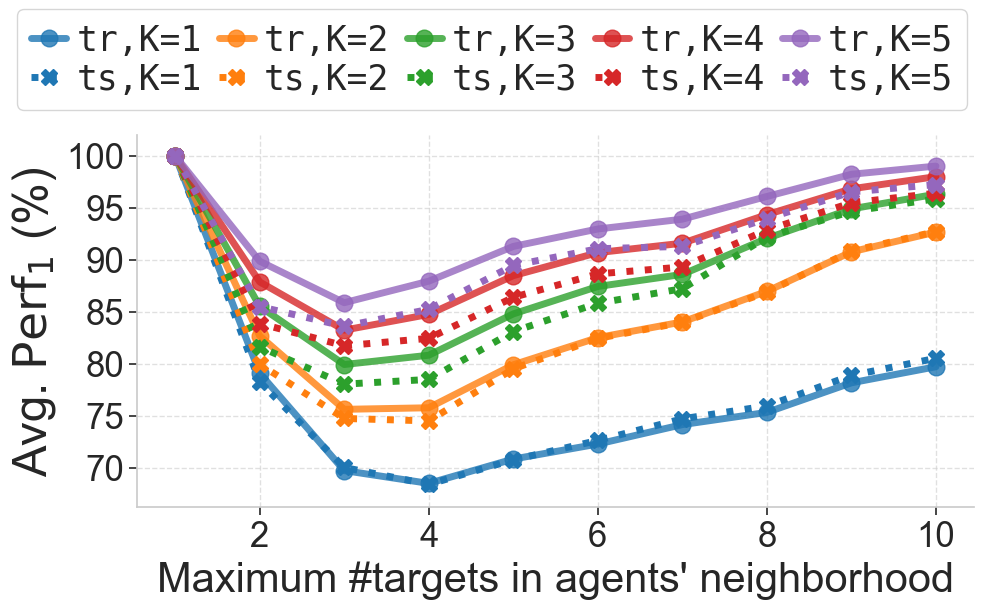

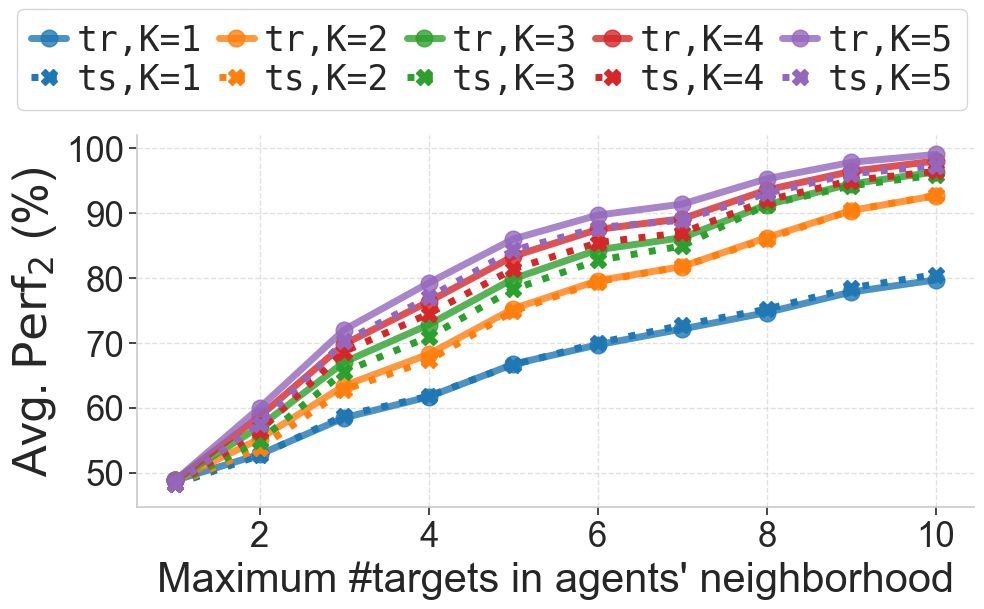

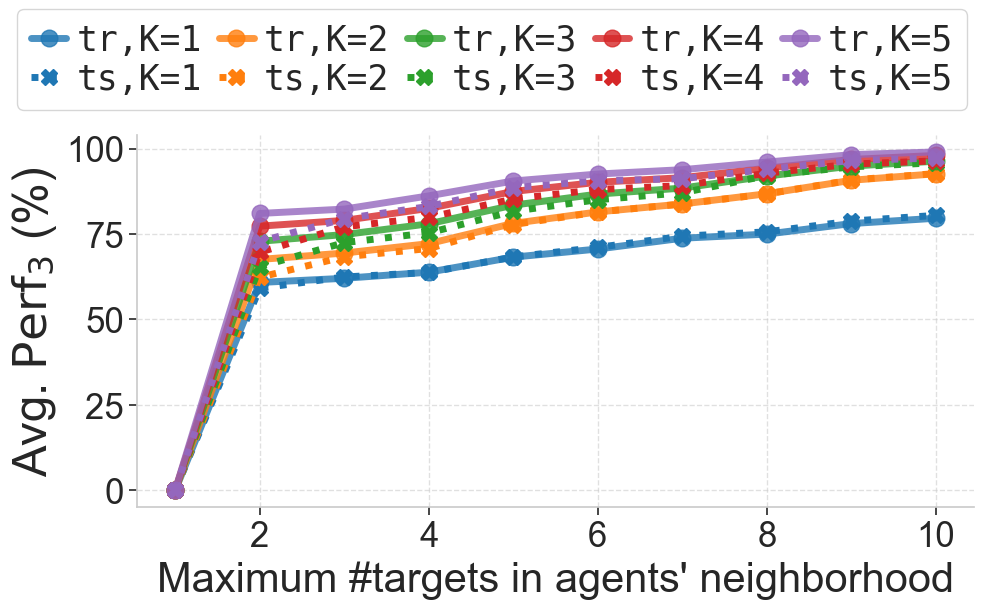

In [9]:
######### exclude: no neighbors and exclusively neg neighbors
scripts.analytics.learnsetting_plot(summary_res=summary_dfx,
                  thresh=False, 
                  perfv="perf1", 
                  save_as="./ls_results/figures/"+dsetname+"_learn_both_results_knn_perf1.pdf")

######### exclude: none
scripts.analytics.learnsetting_plot(summary_res=summary_dfx,
                  thresh=False, 
                  perfv="perf2", 
                  save_as="./ls_results/figures/"+dsetname+"_learn_both_results_knn_perf2.pdf")

######### exclude: no neighbors and exclusively neg/pos neighbors
scripts.analytics.learnsetting_plot(summary_res=summary_dfx,
                  thresh=False, 
                  perfv="perf3", 
                  save_as="./ls_results/figures/"+dsetname+"_learn_both_results_knn_perf3.pdf")

